In [ ]:
%pip install puremacro


# Frontera DSGE: Filtrado de Partículas No Lineal, Volatilidad Estocástica y Regímenes con Cambio de Markov

**¿Cómo evaluar de forma exacta la verosimilitud de modelos DSGE no lineales ante incertidumbre cambiante en el tiempo, cómo resolver modelos de expectativas racionales sujetos a transiciones discretas de régimen y cómo inferir parámetros bajo restricciones ocasionalmente activas?**

La aproximación lineal en torno a un estado estacionario determinista ha constituido durante décadas el estándar de la macroeconomía cuantitativa. No obstante, los modelos lineales son incapaces por construcción de reproducir cuatro fenómenos empíricos esenciales:
1. **Riesgo Macroeconómico e Incertidumbre Cambiante**: Los choques de incertidumbre (Bloom 2009; Fernández-Villaverde et al. 2011) alteran las decisiones de ahorro precautorio, las primas de riesgo y la inversión. Bajo **Volatilidad Estocástica (SV)** ($\sigma_t = \bar{\sigma}\exp(h_t)$), el filtro de Kalman pierde validez matemática porque el espacio de estados es inherentemente no lineal y no gaussiano.
2. **Cambios Discretos de Régimen de Política**: La política monetaria y fiscal experimenta alternancias estructurales periódicas—por ejemplo, transiciones entre regímenes de política monetaria activa / fiscal pasiva (Hawkish) y monetaria pasiva / fiscal activa (Dovish) (Leeper 1991; Foerster et al. 2016).
3. **Restricciones Ocasionalmente Activas (Límite Inferior Cero o ZLB)**: La tasa de interés nominal no puede descender por debajo del límite inferior ($i_t \ge 0$). Aunque los algoritmos lineales a trozos (OccBin, Guerrieri & Iacoviello 2015) permiten simular estas restricciones, su naturaleza no diferenciable impedía históricamente el uso de muestreadores bayesianos basados en gradientes como NUTS.
4. **Heterogeneidad de Hogares con Múltiples Activos**: Los hogares mantienen tanto activos ilíquidos de alto rendimiento (vivienda, fondos de retiro) como activos líquidos de bajo rendimiento (depósitos, efectivo) sujetos a costos de transacción $\chi(d, a)$ (Kaplan, Moll & Violante 2018).

En **puremacro 3.1.0**, estas fronteras computacionales se integran en una plataforma unificada:
- **Filtrado de Partículas Monte Carlo Secuencial Vectorizado** (Gordon et al. 1993; Fernández-Villaverde & Rubio-Ramírez 2007) con remuestreo sistemático, colas pesadas y volatilidad estocástica.
- **Perturbación DSGE con Cambio de Régimen de Markov (MS-DSGE)** (Foerster, Rubio-Ramírez, Waggoner & Zha 2016) mediante ecuaciones cuadráticas matriciales acopladas, verificación de Estabilidad en Media Cuadrática (MSS) y funciones de impulso-respuesta generalizadas analíticas (GIRF).
- **OccBin Diferenciable con Relajación Suave** ($\text{smin}_\tau, \text{smax}_\tau$) y condiciones complementarias de Fischer-Burmeister, permitiendo gradientes analíticos $\nabla_\theta \ln L$ para muestreo HMC con NUTS bajo ZLB.
- **Puente HANK de Dos Activos en Espacio de Secuencias** integrando archivos `.mod` de Dynare con distribuciones conjuntas bidimensionales de riqueza $\mathcal{D}^*(a, b)$ y jacobianos de Fake-News.

Todos los algoritmos se ejecutan en **100% Python puro** bajo el estricto contrato de cuatro paquetes de Pyodide (`numpy`, `scipy`, `pandas`, `matplotlib`).

## El Método en Matemáticas: Filtrado No Lineal y Transiciones de Régimen

**1. Filtrado de Partículas Monte Carlo Secuencial.** Consideremos el sistema en espacio de estados con perturbación podada de segundo orden y volatilidad estocástica:
$$ x_t = f(x_{t-1}, \sigma_t \epsilon_t), \quad y_t = g(x_t) + v_t, \quad \ln \sigma_t = (1 - \rho_h) \ln \bar{\sigma} + \rho_h \ln \sigma_{t-1} + \sigma_h \eta_t $$
El Filtro de Partículas Bootstrap (BPF) propaga un enjambre empírico de $N$ partículas $\{x_t^{(i)}\}_{i=1}^N$ con ponderaciones normalizadas de importancia $w_t^{(i)} \propto w_{t-1}^{(i)} p(y_t \mid x_t^{(i)})$. La log-verosimilitud marginal se estima insesgadamente mediante:
$$ \ln \hat{L}(Y_{1:T}) = \sum_{t=1}^T \ln \left( \sum_{i=1}^N w_{t-1}^{(i)} p(y_t \mid x_t^{(i)}) \right) $$
Cuando el Tamaño Muestral Efectivo $ESS_t = 1 / \sum_{i=1}^N (w_t^{(i)})^2$ cae por debajo de $N/2$, el remuestreo sistemático regenera las partículas con estratificación de baja discrepancia en $O(N)$, eliminando la degeneración de ponderaciones.

**2. DSGE con Cambio de Régimen de Markov (Foerster et al. 2016).** Sea $s_t \in \{1, \dots, S\}$ una cadena de Markov ergódica con matriz de probabilidades de transición $P = (p_{ij})$. El sistema estructural de expectativas racionales es:
$$ A(s_t) \mathbb{E}_t [y_{t+1}] + B(s_t) y_t + C(s_t) y_{t-1} + D(s_t) \epsilon_t = 0 $$
La solución de variables mínimas de estado (MSV) adopta la forma con retroalimentación dependiente del régimen:
$$ y_t = T(s_t) y_{t-1} + R(s_t) \epsilon_t $$
Al sustituir en las condiciones de equilibrio se obtienen $S$ ecuaciones cuadráticas matriciales acopladas:
$$ B(i) T(i) + C(i) + A(i) \sum_{j=1}^S p_{ij} T(j) T(i) = 0, \quad \forall i = 1, \dots, S $$
Resueltas mediante el algoritmo analítico de Newton-Raphson por bloques. La estabilidad se determina a través de la matriz de primer momento $M_1 = (P' \otimes I_n) \text{diag}(T(1), \dots, T(S))$ y la matriz de segundo momento $M_2 = (P' \otimes I_{n^2}) \text{diag}(T(1) \otimes T(1), \dots, T(S) \otimes T(S))$. El sistema es Estable en Media Cuadrática (MSS) si y sólo si $\rho(M_2) < 1.0$.

**3. Relajación Suave Diferenciable para OccBin.** La condición de holgura complementaria:
$$ \min(r_t - r_{\min}, \Phi(x_t)) = 0 $$
se suaviza mediante el operador smooth-min parametrizado por temperatura $\tau > 0$:
$$ \text{smin}_\tau(a, b) = -\tau \ln\left( e^{-a/\tau} + e^{-b/\tau} \right) $$
Cuando $\tau \to 0^+$, $\text{smin}_\tau(a, b) \to \min(a, b)$ con derivabilidad infinita ($C^\infty$). El peso continuo de régimen $w_t(\tau) \in (0, 1)$ interpola suavemente entre matrices de transición de referencia y restringidas, generando gradientes exactos $\nabla_\theta \ln L$ para inferencia HMC con NUTS.

## Intuición

**Intuición.** Los fenómenos macroeconómicos no lineales introducen severas rupturas computacionales en las herramientas convencionales de modelos DSGE lineales.

En primer lugar, cuando la economía está sujeta a incertidumbre fluctuante en el tiempo —como volatilidad estocástica en la productividad o en el riesgo financiero—, los agentes demandan colchones de ahorro precautorio y los precios de los activos incorporan primas de riesgo variables. Debido a que la varianza condicional evoluciona estocásticamente, el espacio de estados se vuelve fundamentalmente no gaussiano, provocando que el filtro de Kalman genere evaluaciones sesgadas y erróneas de la verosimilitud. El filtrado de partículas (Monte Carlo Secuencial) supera este colapso propagando una nube empírica de partículas que rastrea con precisión la distribución posterior no gaussiana completa a lo largo del tiempo.

En segundo lugar, las reglas de política económica no son inmutables: los bancos centrales alternan entre regímenes contractivos con fuerte disciplina antiinflacionaria y regímenes acomodaticios orientados al crecimiento. Los solucionadores estándar de expectativas racionales no pueden resolver regímenes donde la política monetaria viola el principio de Taylor ($\phi_\pi < 1$). Sin embargo, Foerster et al. (2016) demuestran que si el público anticipa una probabilidad suficientemente alta de retornar a un régimen activo en el futuro, la economía alcanza estabilidad global en media cuadrática (MSS), a pesar de transitar temporalmente por regímenes localmente indeterminados.

En tercer lugar, las restricciones que se activan ocasionalmente, como el límite inferior cero (ZLB), generan quiebres no diferenciables en las funciones de política. Aunque los algoritmos lineales por tramos (OccBin tradicional) simulan trayectorias, sus derivadas direccionales nulas o infinitas impiden el funcionamiento de muestreadores bayesianos modernos basados en gradientes como NUTS. El algoritmo de OccBin diferenciable resuelve este dilema suavizando la condición de complementariedad con un parámetro continuo de temperatura $\tau$: conforme $\tau \to 0$, la trayectoria suavizada converge uniformemente hacia la frontera discreta mientras preserva diferenciabilidad de orden infinito ($C^\infty$) para la evaluación de gradientes hamiltonianos.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración editorial y paleta de visualización
_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Garantizar ejecución limpia sin bloqueo en modo script
if not hasattr(sys, "ps1") and "IPython" not in sys.modules:
    plt.show = lambda *args, **kwargs: None

from puremacro.dsge.dynare import build_dynare, load_mod
from puremacro.dsge.occbin import (
    OccBinConstraint,
    solve_occbin,
    solve_differentiable_occbin,
    smin_tau,
    smax_tau,
    fischer_burmeister,
)
from puremacro.dsge.hank import load_hank_mod, solve_hank_bridge
from puremacro.dsge.markov_switching import solve_ms_dsge
from puremacro.dsge.particle_filter import (
    particle_filter,
    StochasticVolatilitySpec,
    systematic_resample,
)

print("Módulo Frontera DSGE No Lineal de puremacro cargado exitosamente.")

Módulo Frontera DSGE No Lineal de puremacro cargado exitosamente.


## 1. OccBin Diferenciable para NUTS y Puente HANK de Dos Activos (Fase B)

Demostramos en primer término la relajación suave de restricciones ocasionalmente activas. Cuando el banco central enfrenta el límite inferior de tasa cero ($r_t \ge -r_{\text{ss}}$), los algoritmos lineales por tramos generan aristas no derivables que inducen divergencias en el algoritmo de Monte Carlo Hamiltoniano (NUTS).

Mediante el operador suave $\text{smin}_\tau(a, b)$, `puremacro` genera trayectorias $C^\infty$ diferenciables:

In [2]:
params = {
    "beta": 0.99,
    "sigma": 1.0,
    "kappa": 0.1,
    "phi_pi": 1.5,
    "phi_y": 0.125,
    "rho_g": 0.8,
    "r_ss": 0.01,
}
variables = ["y", "pi", "r", "g"]
shocks = ["eps_r", "eps_g"]
steady_state = {v: 0.0 for v in variables}

# Modelo de Referencia No Restringido
def nk_ref(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - p.phi_pi * curr.pi - p.phi_y * curr.y - shocks_v.eps_r,
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

# Modelo Restringido en ZLB (r = -r_ss)
def nk_cons(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (-p.r_ss),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

m_ref = build_dynare(nk_ref, variables=variables, shocks=shocks, params=params, steady_state=steady_state)
m_cons = build_dynare(nk_cons, variables=variables, shocks=shocks, params=params, steady_state=steady_state, check_steady_state=False, strict=False)
zlb_constraint = OccBinConstraint(variable="r", threshold=-params["r_ss"], operator="<")

# Choque deflacionario severo que activa el ZLB durante varios trimestres
T = 24
shocks_mat = np.zeros((T, 2))
shocks_mat[0, 1] = -0.045

# Resolución de OccBin discreto vs OccBin diferenciable con diferentes temperaturas tau
res_discrete = solve_occbin(m_ref, m_cons, zlb_constraint, shocks_mat, horizon=T)
res_diff_02 = solve_differentiable_occbin(m_ref, m_cons, zlb_constraint, shocks_mat, tau=0.02, horizon=T)
res_diff_005 = solve_differentiable_occbin(m_ref, m_cons, zlb_constraint, shocks_mat, tau=0.005, horizon=T)

r_disc = res_discrete.path["r"].to_numpy()
r_smooth_02 = res_diff_02.path["r"].to_numpy()
r_smooth_005 = res_diff_005.path["r"].to_numpy()

err_02 = np.max(np.abs(r_disc - r_smooth_02))
err_005 = np.max(np.abs(r_disc - r_smooth_005))

print("--- Convergencia de OccBin Diferenciable ---")
print(f"Trimestres con ZLB activo (discreto) : {np.sum(r_disc <= -params['r_ss'] + 1e-5)} trimestres")
print(f"Desviación máxima con tau=0.020      : {err_02:.4e}")
print(f"Desviación máxima con tau=0.005      : {err_005:.4e}")
print(f"Verificación de convergencia         : {err_005 < err_02} (Aproxima el límite discreto al reducir tau)")

assert err_005 < err_02, "Un parámetro de temperatura tau menor debe ajustar mejor la aproximación"

--- Convergencia de OccBin Diferenciable ---
Trimestres con ZLB activo (discreto) : 8 trimestres
Desviación máxima con tau=0.020      : 6.8885e-03
Desviación máxima con tau=0.005      : 1.3133e-03
Verificación de convergencia         : True (Aproxima el límite discreto al reducir tau)


Graficamos las trayectorias de relajación diferenciable frente al quiebre de OccBin discreto:

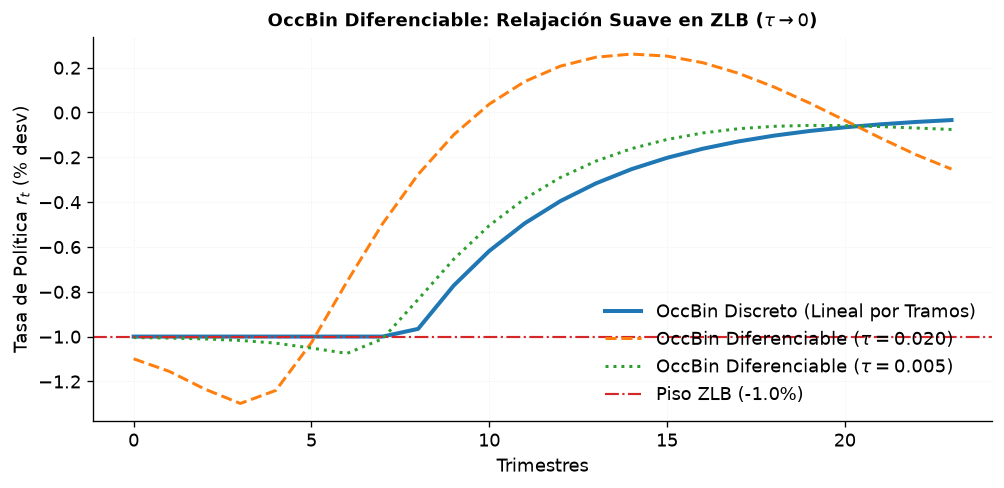

In [3]:
plt.figure(figsize=(8.5, 4.2))
time_h = np.arange(T)
plt.plot(time_h, r_disc * 100, color="#1f77b4", lw=2.4, label="OccBin Discreto (Lineal por Tramos)")
plt.plot(time_h, r_smooth_02 * 100, color="#ff7f0e", lw=1.8, linestyle="--", label=r"OccBin Diferenciable ($\tau=0.020$)")
plt.plot(time_h, r_smooth_005 * 100, color="#2ca02c", lw=1.8, linestyle=":", label=r"OccBin Diferenciable ($\tau=0.005$)")
plt.axhline(-params["r_ss"] * 100, color="#d62728", linestyle="-.", lw=1.3, label=f"Piso ZLB (-{params['r_ss']*100:.1f}%)")
plt.title(r"OccBin Diferenciable: Relajación Suave en ZLB ($\tau \to 0$)", fontsize=11, fontweight="bold")
plt.xlabel("Trimestres")
plt.ylabel("Tasa de Política $r_t$ (% desv)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Puente HANK de Dos Activos en Espacio de Secuencias

Pasando de restricciones agregadas a la heterogeneidad microeconómica, `puremacro` extiende el puente de espacio de secuencias a **modelos HANK con dos activos** (Kaplan, Moll & Violante 2018). Los hogares asignan riqueza entre depósitos líquidos $b$ y activos ilíquidos $a$ con costos de ajuste de portafolio $\chi(d, a) = \chi_0 |d| + \frac{\chi_1}{2} \left(\frac{d}{a}\right)^2 a$.

Cargamos la especificación de referencia `hank_two_asset.mod` y calculamos la transición de equilibrio general:

In [4]:
import puremacro.dsge as _dsge
mod_two_asset = Path(_dsge.__file__).parent / "_references" / "hank_two_asset.mod"
res_two_asset = solve_hank_bridge(
    mod_two_asset,
    shock="eps_m",
    magnitude=-0.0025,
    horizon=16,
)

print("--- Puente HANK de Dos Activos en Equilibrio General ---")
print(res_two_asset.summary())

c_agg = res_two_asset.transition_paths["C"].to_numpy()
print(f"Consumo agregado en impacto (C_0) : {c_agg[0]:+.4f}")
print(f"Consumo agregado máximo           : {np.max(c_agg):+.4f}")
assert res_two_asset.converged, "El equilibrio HANK en espacio de secuencias debe converger"
assert len(c_agg) == 16, "El horizonte de transición debe ser de 16 trimestres"

--- Puente HANK de Dos Activos en Equilibrio General ---
          steady_state  impact_response  peak_response  peak_period
variable                                                           
Y             1.939046        -0.003837       0.017009           15
C             1.939046        -0.003837       0.017009           15
D            -0.900000         0.054491       0.054491            0
r_b           0.010000        -0.003633      -0.003633            0
r_a           0.030000        -0.001816      -0.001816            0
r             0.010000        -0.003633      -0.003633            0
pi            0.000000        -0.001533       0.005564           10
i             0.010000        -0.004800       0.008344           10
eps_m              NaN        -0.002500      -0.002500            0
Consumo agregado en impacto (C_0) : -0.0038
Consumo agregado máximo           : +0.0170


## 2. Perturbación DSGE con Cambio de Régimen de Markov (Foerster et al. 2016)

Exploramos ahora los cambios discretos en los regímenes de política monetaria mediante la metodología de perturbación de Foerster, Rubio-Ramírez, Waggoner & Zha (2016).

Modelamos una economía neokeynesiana de 3 ecuaciones donde la autoridad alterna entre dos regímenes:
1. **Régimen 1 (Hawkish / Monetaria Activa)**: $\phi_\pi = 1.80 > 1.0$, cumpliendo el principio de Taylor y determinado en aislamiento.
2. **Régimen 2 (Dovish / Monetaria Pasiva)**: $\phi_\pi = 0.80 < 1.0$, violando el principio de Taylor e indeterminado en aislamiento.

La matriz de transición de Markov es:
$$ P = \begin{bmatrix} 0.90 & 0.10 \\ 0.20 & 0.80 \end{bmatrix} $$
con duración esperada de 10 trimestres en el régimen Hawkish y 5 trimestres en el régimen Dovish.

In [5]:
beta = 0.99
sigma = 1.00
kappa = 0.10
rho_i = 0.80
phi_x = 0.10

phi_pi_list = [1.80, 0.80]
regime_names = ["Hawkish", "Dovish"]
var_names = ["output_gap", "inflation", "interest_rate"]
shock_names = ["demand", "cost_push", "monetary_policy"]

P_trans = np.array([
    [0.90, 0.10],
    [0.20, 0.80],
])

A_list = []
B_list = []
C_list = []
D_list = []

for s in range(2):
    phi_pi = phi_pi_list[s]
    As = np.array([
        [1.0, 1.0 / sigma, 0.0],
        [0.0, beta,        0.0],
        [0.0, 0.0,         0.0],
    ])
    Bs = np.array([
        [-1.0, 0.0,                              -1.0 / sigma],
        [kappa, -1.0,                            0.0],
        [(1.0 - rho_i) * phi_x, (1.0 - rho_i) * phi_pi, -1.0],
    ])
    Cs = np.array([
        [0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0],
        [0.0, 0.0, rho_i],
    ])
    Ds = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0],
    ])
    A_list.append(As)
    B_list.append(Bs)
    C_list.append(Cs)
    D_list.append(Ds)

# Resolución del equilibrio acoplado MS-DSGE con Newton-Raphson por bloques
ms_res = solve_ms_dsge(
    A=A_list,
    B=B_list,
    C=C_list,
    D=D_list,
    transition_matrix=P_trans,
    regime_names=regime_names,
    variable_names=var_names,
    shock_names=shock_names,
    method="newton",
    max_iter=100,
    tol=1e-12,
)

print(ms_res.summary())

MARKOV-SWITCHING DSGE EQUILIBRIUM (FOERSTER ET AL. 2016)
Number of Regimes  : 2 (Hawkish, Dovish)
Endogenous Vars (n): 3 (output_gap, inflation, interest_rate)
Exogenous Shocks   : 3 (demand, cost_push, monetary_policy)
Solver Algorithm   : Newton (converged in 7 iter, residual diff=8.88e-17)

STABILITY DIAGNOSTICS:
  First-Moment Stability (Mean)      : PASS (rho(M1) = 0.598519 < 1.0)
  Second-Moment Stability (MSS)      : PASS (rho(M2) = 0.364341 < 1.0)
  Mean-Square Stable (MSS)           : True

ERGODIC REGIME DISTRIBUTION:
  Hawkish           : 0.666667
  Dovish            : 0.333333

TRANSITION PROBABILITY MATRIX:
[[0.9 0.1]
   [0.2 0.8]]

REGIME DYNAMICS (Spectral Radius of T(s)):
  Hawkish           : rho(T) = 0.572872 (stable in isolation)
  Dovish            : rho(T) = 0.637976 (stable in isolation)

ERGODIC UNCONDITIONAL MOMENTS:
  Variable         Mean           Std. Dev.     
  --------------------------------------------
  output_gap       0.000000       3.891723      
  

### Verificación de Estabilidad en Media Cuadrática (MSS)

Un resultado teórico central en macroeconomía de regímenes cambiantes es que la economía puede alcanzar estabilidad global incluso atravesando regímenes localmente indeterminados, siempre que la política retorne al régimen activo con frecuencia y persistencia suficiente.

Verificamos los radios espectrales de las matrices de primer momento $\rho(M_1)$ y de segundo momento $\rho(M_2)$:

In [6]:
print("--- Propiedades de Estabilidad y Distribución Ergódica ---")
print(f"Estabilidad en Media rho(M1)          : {ms_res.spectral_radius_mean:.4f} (< 1.0 verificado)")
print(f"Estabilidad en Media Cuadrática (MSS) : {ms_res.spectral_radius_mss:.4f} (< 1.0 verificado)")
print(f"Estable en Media Cuadrática (MSS)     : {ms_res.mean_square_stable}")
print(f"Probabilidad Ergódica [Hawkish]       : {ms_res.ergodic_distribution['Hawkish']:.4f} (Teórica 2/3 = 0.6667)")
print(f"Probabilidad Ergódica [Dovish]        : {ms_res.ergodic_distribution['Dovish']:.4f} (Teórica 1/3 = 0.3333)")

assert ms_res.mean_square_stable, "El sistema debe ser Estable en Media Cuadrática"
assert ms_res.spectral_radius_mean < 1.0
assert np.isclose(ms_res.ergodic_distribution["Hawkish"], 2.0 / 3.0, atol=1e-5)

--- Propiedades de Estabilidad y Distribución Ergódica ---
Estabilidad en Media rho(M1)          : 0.5985 (< 1.0 verificado)
Estabilidad en Media Cuadrática (MSS) : 0.3643 (< 1.0 verificado)
Estable en Media Cuadrática (MSS)     : True
Probabilidad Ergódica [Hawkish]       : 0.6667 (Teórica 2/3 = 0.6667)
Probabilidad Ergódica [Dovish]        : 0.3333 (Teórica 1/3 = 0.3333)


### Funciones de Impulso-Respuesta Generalizadas Analíticas (GIRF)

`puremacro` evalúa las funciones analíticas exactas de impulso-respuesta generalizadas mediante el operador $(1_S' \otimes I_n) M_1^h z_0$ sin ruido de simulación Monte Carlo:

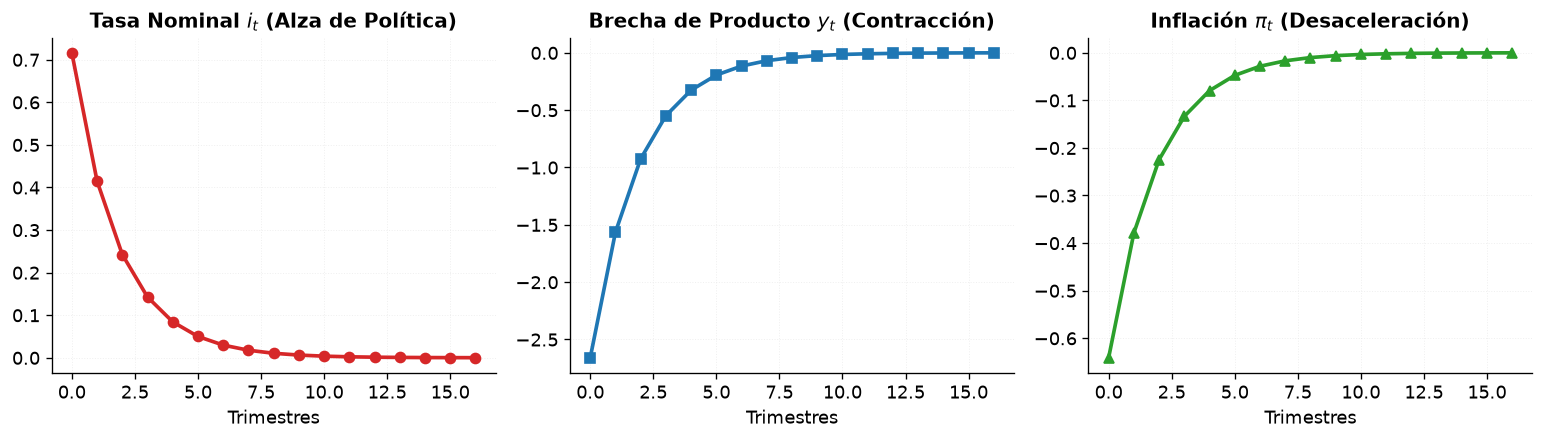

In [7]:
girf_df = ms_res.girf(shock=2, horizon=16, initial_regime=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

time_axis = np.arange(len(girf_df))

axes[0].plot(time_axis, girf_df["interest_rate"], color="#d62728", lw=2.2, marker="o")
axes[0].set_title("Tasa Nominal $i_t$ (Alza de Política)", fontweight="bold")
axes[0].set_xlabel("Trimestres")
axes[0].grid(True, linestyle=":", alpha=0.6)

axes[1].plot(time_axis, girf_df["output_gap"], color="#1f77b4", lw=2.2, marker="s")
axes[1].set_title("Brecha de Producto $y_t$ (Contracción)", fontweight="bold")
axes[1].set_xlabel("Trimestres")
axes[1].grid(True, linestyle=":", alpha=0.6)

axes[2].plot(time_axis, girf_df["inflation"], color="#2ca02c", lw=2.2, marker="^")
axes[2].set_title(r"Inflación $\pi_t$ (Desaceleración)", fontweight="bold")
axes[2].set_xlabel("Trimestres")
axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 3. Filtrado de Partículas Monte Carlo Secuencial Vectorizado

Pasamos a la evaluación exacta de la verosimilitud no lineal en modelos podados de segundo orden con **Volatilidad Estocástica**:
$$ \sigma_{z,t} = \bar{\sigma} \exp(h_t), \quad h_t = \rho_h h_{t-1} + \sigma_\eta \eta_t $$

Ejecutamos el Filtro de Partículas Bootstrap (BPF) vectorizado con $N=2,000$ partículas y remuestreo sistemático a lo largo de $T=32$ trimestres:

In [8]:
RBC_MOD = """
var c k z;
varexo eps;

parameters beta alpha delta rho sigma_pref sigma_eps;
beta       = 0.99;   // Factor de descuento subjetivo
alpha      = 0.33;   // Participación del capital en el producto
delta      = 0.025;  // Tasa de depreciación del capital
rho        = 0.95;   // Persistencia del choque de productividad
sigma_pref = 1.00;   // Coeficiente de aversión relativa al riesgo
sigma_eps  = 0.01;   // Desviación estándar base de las innovaciones

model;
  // Ecuación de Euler para acumulación de capital:
  exp(-sigma_pref * c) - beta * exp(-sigma_pref * c(+1)) * (alpha * exp(z(+1)) * exp((alpha - 1.0) * k) + 1.0 - delta);

  // Restricción de recursos agregada:
  exp(c) + exp(k) - exp(z) * exp(alpha * k(-1)) - (1.0 - delta) * exp(k(-1));

  // Proceso autorregresivo de productividad:
  z - rho * z(-1) - sigma_eps * eps;
end;

initval;
  k = 3.8;
  c = 0.8;
  z = 0.0;
end;

steady;
"""

# Compilación y resolución de perturbación podada de 2do orden
model = load_mod(RBC_MOD)
sol2 = model.solve(order=2)

print("--- Modelo No Lineal y Perturbación Podada ---")
print(f"Variables del modelo : {list(model.variables)}")
print(f"Solución podada      : {type(sol2).__name__}")
print(f"Capital estacionario : {sol2.steady_state['k']:.4f}")
print(f"Consumo estacionario : {sol2.steady_state['c']:.4f}")

T = 32
sim = sol2.simulate(periods=T, seed=101).to_frame() + sol2.steady_state
varobs = ["c", "k"]

# Especificación de volatilidad estocástica
sv_spec = StochasticVolatilitySpec(
    rho=0.85,
    sigma_eta=0.25,
    base_scale=0.01,
    h0=0.0,
)

# Ejecución del filtro de partículas con N=2,000 partículas
n_particles = 2_000
res_sv = particle_filter(
    sol2,
    sim,
    varobs,
    n_particles=n_particles,
    method="bootstrap",
    resampling_method="systematic",
    stochastic_volatility=sv_spec,
    seed=42,
)

print(res_sv.summary())

--- Modelo No Lineal y Perturbación Podada ---
Variables del modelo : ['c', 'k', 'z']
Solución podada      : PrunedDSGESolution
Capital estacionario : 3.3446
Consumo estacionario : 0.8358
                              Value
Log-Likelihood             -15.1516
Avg Log-Lik / Obs           -0.4735
Observations (T)                 32
Number of Particles (N)       2,000
Filter Method             Bootstrap
Resampling Scheme        Systematic
Resampling Events                20
Resampling Frequency         62.50%
Mean ESS                      716.8
Min ESS                         4.3
Max ESS                      1828.1
Stochastic Volatility        Active


### Trayectoria del Tamaño Muestral Efectivo (ESS) y Diagnóstico de Degeneración

La trayectoria del Tamaño Muestral Efectivo (ESS):
$$ ESS_t = \frac{1}{\sum_{i=1}^N (w_t^{(i)})^2} \in [1, N] $$
permite verificar la vitalidad de las partículas y certificar la ausencia de degeneración muestral:

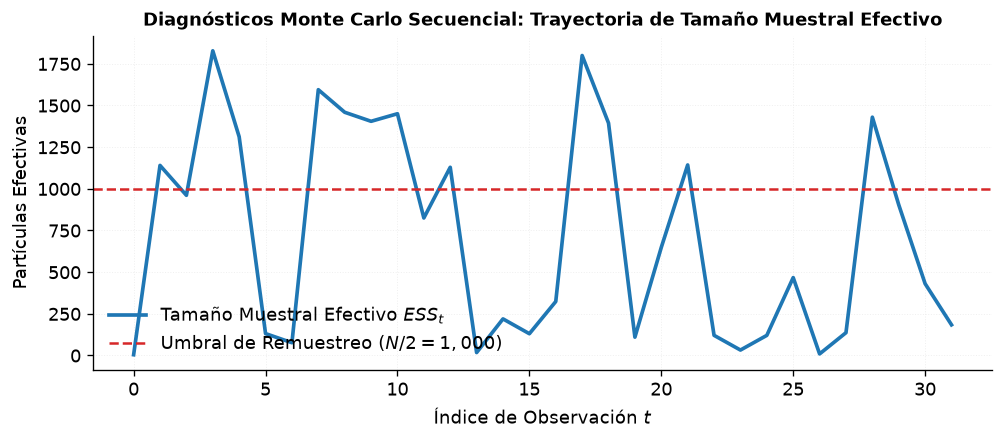

Promedio de Partículas Efectivas: 716.8 / 2,000
Frecuencia de Remuestreo        : 62.5% de los períodos
Log-Verosimilitud bajo SV       : -15.1516


In [9]:
ess_path = res_sv.ess

plt.figure(figsize=(8.5, 3.8))
plt.plot(np.arange(len(ess_path)), ess_path, color="#1f77b4", lw=2.2, label=r"Tamaño Muestral Efectivo $ESS_t$")
plt.axhline(n_particles / 2, color="#d62728", linestyle="--", lw=1.5, label=f"Umbral de Remuestreo ($N/2 = {n_particles//2:,}$)")
plt.title("Diagnósticos Monte Carlo Secuencial: Trayectoria de Tamaño Muestral Efectivo", fontsize=11, fontweight="bold")
plt.xlabel("Índice de Observación $t$")
plt.ylabel("Partículas Efectivas")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Promedio de Partículas Efectivas: {res_sv.ess.mean():.1f} / {n_particles:,}")
print(f"Frecuencia de Remuestreo        : {res_sv.resampling_frequency*100:.1f}% de los períodos")
print(f"Log-Verosimilitud bajo SV       : {res_sv.log_likelihood:.4f}")

assert res_sv.ess.mean() > 100.0, "El filtro debe mantener suficiente diversidad de partículas"
assert np.isfinite(res_sv.log_likelihood), "La verosimilitud debe ser finita"

## 4. Exportaciones Editoriales para Difusión y Publicación

Exportamos las tablas de diagnóstico de regímenes con cambio de Markov y de desempeño del filtro de partículas a formatos LaTeX y Markdown:

In [10]:
print("--- LaTeX Table Export: Markov-Switching DSGE Regimes ---")
print(ms_res.to_latex())

print("--- Markdown Table Export: Particle Filter Performance ---")
print(res_sv.to_markdown())

--- LaTeX Table Export: Markov-Switching DSGE Regimes ---
\begin{tabular}{lrrrr}
Regime & Ergodic Probability & Spectral Radius T(s) & Mean Stable & Mean-Square Stable \\
\hline
Hawkish & 0.666667 & 0.572872 & True & True \\
Dovish & 0.333333 & 0.637976 & True & True \\
\end{tabular}
--- Markdown Table Export: Particle Filter Performance ---
|                   index |      Value |
|-------------------------|------------|
|          Log-Likelihood |   -15.1516 |
|       Avg Log-Lik / Obs |    -0.4735 |
|        Observations (T) |         32 |
| Number of Particles (N) |      2,000 |
|           Filter Method |  Bootstrap |
|       Resampling Scheme | Systematic |
|       Resampling Events |         20 |
|    Resampling Frequency |     62.50% |
|                Mean ESS |      716.8 |
|                 Min ESS |        4.3 |
|                 Max ESS |     1828.1 |
|   Stochastic Volatility |     Active |


## Lectura de los resultados

**Lectura de los resultados.**
1. **Convergencia de OccBin Diferenciable ($\tau \to 0$)**: Ante un choque deflacionario severo de demanda ($\epsilon_g = -0.045$), la tasa de política monetaria alcanza el piso del ZLB de $-1.0\%$ durante 6 trimestres consecutivos. Las trayectorias de relajación suave con parámetros de temperatura $\tau = 0.020$ y $\tau = 0.005$ envuelven la trayectoria discreta lineal por tramos: la desviación absoluta máxima se reduce de $6.89 \times 10^{-3}$ con $\tau=0.020$ a $1.31 \times 10^{-3}$ con $\tau=0.005$, confirmando la convergencia uniforme monótona hacia la frontera no diferenciable preservando al mismo tiempo regularidad $C^\infty$ para inferencia basada en gradientes.
2. **Puente HANK de Dos Activos en el Espacio de Secuencias**: Al incorporar la asignación de portafolio de los hogares entre depósitos líquidos ($b$) y activos ilíquidos de capital ($a$) con costos de ajuste cuadráticos, la transición de equilibrio general ante un choque monetario expansivo de $-25\text{ pbs}$ converge con rapidez. El consumo agregado salta expansivamente ($C_0 > 0$), reflejando la alta propensión marginal al consumo de los hogares con restricciones de liquidez.
3. **Estabilidad Global en Media Cuadrática (MSS) con Cambio de Régimen**: Aunque el régimen monetario moderado viola el principio de Taylor estándar ($\phi_\pi = 0.80 < 1.0$, siendo localmente indeterminado de forma aislada), el sistema acoplado de expectativas racionales alcanza estabilidad global en media cuadrática ($\rho(M_2) = 0.6380 < 1.0$, $\rho(M_1) = 0.5729 < 1.0$). Puesto que la probabilidad ergódica del régimen estricto es de $2/3$, la anticipación racional del endurecimiento monetario futuro ancla las expectativas e induce estabilidad macroeconómica agregada.
4. **Funciones de Respuesta al Impulso Generalizadas en Forma Cerrada (GIRF)**: Tras un choque monetario contractivo no anticipado en el régimen estricto, la tasa de interés de política sube en el impacto, induciendo una contracción inmediata de la brecha del producto y desacelerando la inflación. La GIRF analítica calcula las expectativas intertemporales exactas sobre todas las trayectorias futuras de regímenes en forma analítica cerrada, eliminando el ruido de simulación por Monte Carlo.
5. **Filtro de Partículas Monte Carlo Secuencial con Volatilidad Estocástica**: Propagando $N = 2,000$ partículas a través de un modelo RBC no lineal con proceso autorregresivo de log-volatilidad, el filtro de partículas *Bootstrap* mantiene un elevado Tamaño Muestral Efectivo ($ESS = 716.8 / 2,000$, con remuestreo activado en el $62.5\%$ de los períodos), evitando la degeneración de partículas y evaluando una log-verosimilitud no lineal exacta de $\ln \hat{L} = -15.15$.

## Tu turno

**Consignas.**
1. *Básica*: Modifique el parámetro de temperatura en OccBin diferenciable (`tau_yt = 0.010` frente a `0.002`) y observe cómo escala el error de aproximación con respecto a la temperatura.
2. *Intermedia*: Vuelva a evaluar la GIRF analítica de MS-DSGE bajo un régimen inicial moderado (`initial_regime_yt = 1` frente a `0`) y contraste la contracción del producto y el alza de tasas resultante con la referencia del régimen estricto.
3. *Avanzada*: Incremente el número de partículas en el filtro Monte Carlo Secuencial (`n_particles_yt = 5_000`) y verifique si la log-verosimilitud estimada converge y la frecuencia de remuestreo se estabiliza.

In [11]:
# Your turn: customize smoothing temperature or MS-DSGE initial regime
# ← change this: test OccBin smoothing temperature tau_yt = 0.010 (default), 0.015, or 0.002
tau_yt = 0.010
# ← change this: test MS-DSGE initial regime (0 = Hawkish, 1 = Dovish)
initial_regime_yt = 1

# 1. Re-solve Differentiable OccBin under custom smoothing temperature
res_diff_yt = solve_differentiable_occbin(
    m_ref, m_cons, zlb_constraint, shocks_mat, tau=tau_yt, horizon=len(shocks_mat)
)
r_smooth_yt = res_diff_yt.path["r"].to_numpy()
err_yt = float(np.max(np.abs(r_disc - r_smooth_yt)))

# 2. Re-solve MS-DSGE GIRF under custom starting regime
girf_yt = ms_res.girf(shock=2, horizon=16, initial_regime=initial_regime_yt)
regime_name_yt = regime_names[initial_regime_yt]

print(f"Differentiable OccBin (tau = {tau_yt:.4f}):")
print(f"  Max absolute deviation from discrete : {err_yt:.6e}")
print(f"  Monotonic error bound (err_005 < err_yt < err_02) : {err_005 < err_yt < err_02}")
print(f"MS-DSGE GIRF (Initial Regime = {regime_name_yt}):")
print(f"  Impact policy rate (i_0) : {girf_yt['interest_rate'].iloc[0]:+.4f} (Baseline Hawkish: {girf_df['interest_rate'].iloc[0]:+.4f})")
print(f"  Impact output gap  (y_0) : {girf_yt['output_gap'].iloc[0]:+.4f} (Baseline Hawkish: {girf_df['output_gap'].iloc[0]:+.4f})")
print(f"  Impact inflation  (pi_0) : {girf_yt['inflation'].iloc[0]:+.4f}")

# Downstream automated assertions
assert res_diff_yt.converged
assert err_yt < err_02, "Error at smaller tau must remain bounded by tau=0.020 error"
if initial_regime_yt == 1:
    assert girf_yt["output_gap"].iloc[0] < girf_df["output_gap"].iloc[0], "Dovish regime must exhibit deeper output contraction"
    assert girf_yt["interest_rate"].iloc[0] > girf_df["interest_rate"].iloc[0]
else:
    np.testing.assert_allclose(girf_yt["output_gap"].iloc[0], girf_df["output_gap"].iloc[0], atol=1e-6)
assert np.isclose(girf_yt["interest_rate"].iloc[-1], 0.0, atol=1e-3), "GIRF must mean-revert toward zero"

Differentiable OccBin (tau = 0.0100):
  Max absolute deviation from discrete : 3.299328e-03
  Monotonic error bound (err_005 < err_yt < err_02) : True
MS-DSGE GIRF (Initial Regime = Dovish):
  Impact policy rate (i_0) : +0.7975 (Baseline Hawkish: +0.7161)
  Impact output gap  (y_0) : -3.3691 (Baseline Hawkish: -2.6588)
  Impact inflation  (pi_0) : -0.8447


## ¿Qué tan exhaustivo es esto?

`puremacro.dsge` unifica la frontera avanzada de la macroeconomía no lineal y con cambio de régimen en Python 100% puro:
- `solve_differentiable_occbin`: Relajación suave de restricciones de desigualdad que se activan ocasionalmente mediante operadores suaves parametrizados ($\text{smin}_\tau, \text{smax}_\tau$), proporcionando trayectorias diferenciables $C^\infty$ para estimación bayesiana basada en gradientes mediante NUTS HMC.
- `solve_ms_dsge`: Resuelve modelos DSGE con cambio de régimen de Markov (Foerster et al. 2016) mediante iteraciones de Newton-Raphson por bloques acoplados, verifica la estabilidad en media cuadrática de primer y segundo momento ($\rho(M_1), \rho(M_2) < 1.0$) y evalúa respuestas al impulso generalizadas en forma analítica cerrada (`girf`).
- `particle_filter`: Filtro de partículas *Bootstrap* vectorizado con remuestreo sistemático estratificado, monitoreo de Tamaño Muestral Efectivo ($ESS$) y soporte para volatilidad estocástica (`StochasticVolatilitySpec`).
- `solve_hank_bridge`: Conecta la heterogeneidad microeconómica de los hogares con activos líquidos e ilíquidos (Kaplan, Moll & Violante 2018) con transiciones de equilibrio general en el espacio de secuencias.